In [1]:
import sys
sys.path.append("..")

In [2]:
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import DataLoader

from data_utils.scan_helpers import (
    download_scan_simple_split,
    download_scan_add_prim_split,
    load_scan_split,
    build_vocab,
    PAD,
    BOS,
    EOS,
)

from evaluation.scan_evaluation import (
    greedy_decode,
    sequence_accuracy,
    evaluate_sequence_accuracy,
    ordered_sequence_token_accuracy,   
    evaluate_ordered_token_accuracy,
    evaluate_teacher_forced_ordered_token_accuracy,
    teacher_forced_ordered_sequence_accuracy,
    evaluate_token_level,
    tokens_accuracy,
)

from training.train import (
    train_model,
)

from result_utils.save_results import (
    save_experiment_results,
    load_experiment_results,
)

from result_utils.plot_results import (
    exp3_plot_token_accuracy,
    exp3_plot_sequence_accuracy,
    exp3_part1_plot_token_accuracy,
    exp3_part1_plot_sequence_accuracy,
    exp1_plot_sequence_accuracy,
    exp2_plot_sequence_accuracy,
    exp2_plot_token_accuracy,
)

from data_utils.scan_dataset import ScanDataset
from data_utils.scan_dataloader import collate_scan_batch

from models.transformer import Transformer

In [3]:
SEED_BASE = 42

In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'{device} - {device_name}')

PyTorch version: 2.5.1
CUDA available: True
cuda - NVIDIA GeForce GTX 1050 Ti with Max-Q Design


In [5]:
# Replaced by train_model function in training/train.py, but did not want to delete it
import random


def train(
    model,
    train_loader,
    all_test_loaders,
    optimizer,
    criterion,
    device,
    max_samples = 100_000,
    total_samples = 0,
    grad_clip=1.0,
    use_scheduled_sampling = False
):
    epoch = 0
    running_loss = 0.0
    model.train()
    while total_samples < max_samples:
        epoch += 1
        print(f"Epoch {epoch} | Samples processed: {total_samples}/{max_samples}")
    
        

        for batch_idx, (source_seq, target_input, target_output) in enumerate(train_loader, start=1):
            if total_samples >= max_samples:
                break
            source_seq = source_seq.to(device)
            target_input = target_input.to(device)
            target_output = target_output.to(device)

            optimizer.zero_grad()
            # Scheduled sampling: 50% of batches use self-produced outputs
            if use_scheduled_sampling and random.random() < 0.5:
                # Use self-produced outputs for this entire batch
                with torch.no_grad():
                    pred_logits = model(source_seq, target_input)
                    preds = pred_logits.argmax(dim=-1)
                
                # Replace all positions (except BOS) with model predictions
                tgt_in_mixed = preds.clone()
                tgt_in_mixed[:, 0] = BOS  # Keep BOS token as ground truth
                logits = model(source_seq, tgt_in_mixed)
            else:
                # Pure teacher forcing (ground truth)
                logits = model(source_seq, target_input)

            loss = criterion(
                logits.view(-1, logits.size(-1)),
                target_output.view(-1),
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()
            total_samples += source_seq.size(0)  # Count actual samples in this batch
            running_loss += loss.item()
            
        
            if batch_idx % 500 == 0:
                print(f"  batch {batch_idx} | samples: {total_samples}/{max_samples} | loss {running_loss/500:.4f}")
                running_loss = 0.0


        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={running_loss/len(train_loader):.4f} | "
            #f"val_loss={val_loss:.4f} | "
            #f"token_acc={val_tok_acc*100:.2f}% | "
            #f"seq_acc={val_seq_acc*100:.2f}%"
            )

    print("training complete.")

    #print(f"Final sequence accuracy: {final_seq_acc * 100:.2f}%")

    return model


In [6]:
# def evaluate(all_test_loaders, model, criterion, device):
#     results = {}
#     for key, value in all_test_loaders.items():
#         print(f"Evaluating on {key} length splits:")
#         for length, loader in value.items():
#             seq_acc = evaluate_sequence_accuracy(
#                 model, loader, device
#             )
#             tok_loss, tok_acc = evaluate_token_level(
#                 model, loader, criterion, device
#             )

#             seq_acc_w_oracle = evaluate_sequence_accuracy(
#                 model, loader, device, use_oracle=True
#             )

#             tok_loss, tok_acc_w_oracle = evaluate_token_level(
#                 model, loader, criterion, device, use_oracle=True
#             )
#             # structure results as a dictionary
#             results[(key, length, "with_oracle")] = (seq_acc_w_oracle, tok_acc_w_oracle)
#             results[(key, length, "without_oracle")] = (seq_acc, tok_acc)
#             print(
#                 f"  Length {length}: "
#                 f"Seq Acc (w/o oracle): {seq_acc * 100}%, "
#                 f"Tok Acc (w/o oracle): {tok_acc * 100}%, "
#                 f"Seq Acc (w/ oracle): {seq_acc_w_oracle * 100}%, "
#                 f"Tok Acc (w/ oracle): {tok_acc_w_oracle * 100}%"
#             )
#             #print(f"  Length {length}: {seq_acc * 100:.2f}%")
#     return results


In [7]:
def evaluate(all_test_loaders, model, criterion, device):
    run_results = {
        "source_length": {"without_oracle": {}, "with_oracle": {}},
        "target_length": {"without_oracle": {}, "with_oracle": {}},
    }

    for split_type, loaders in all_test_loaders.items():
        for length, loader in loaders.items():
            # without oracle
            seq_acc = evaluate_sequence_accuracy(model, loader, device, use_oracle=False)
            tok_acc = evaluate_token_level(model, loader, criterion, device, use_oracle=False)

            # with oracle
            seq_acc_oracle = evaluate_sequence_accuracy(
                model, loader, device, use_oracle=True
            )
            tok_acc_oracle = evaluate_token_level(
                model, loader, criterion, device, use_oracle=True
            )

            run_results[split_type]["without_oracle"][int(length)] = {
                "seq": seq_acc,
                "tok": tok_acc,
            }
            run_results[split_type]["with_oracle"][int(length)] = {
                "seq": seq_acc_oracle,
                "tok": tok_acc_oracle,
            }

    return run_results


In [8]:
dataset_pairs = []

train_path = f"data/length_split//tasks_train_length.txt"
test_path  = f"data/length_split//tasks_test_length.txt"

train_inputs, train_outputs = load_scan_split(train_path)
test_inputs, test_outputs   = load_scan_split(test_path)

source_vocab = build_vocab(train_inputs)
target_vocab = build_vocab(train_outputs)

train_dataset = ScanDataset(train_inputs, train_outputs, source_vocab, target_vocab)
test_dataset = ScanDataset(test_inputs, test_outputs, source_vocab, target_vocab)

In [9]:
## Hyperparameters as specified in the assignment for experiment 2
EMB_DIM = 128
N_LAYERS = 2
N_HEADS = 8
FORWARD_DIM = 256
DROPOUT = 0.15
LEARNING_RATE = 2e-4
GRAD_CLIP = 1.0
BATCH_SIZE = 16
NUM_WORKERS = 1

In [10]:
#2 split by source-sequence & target-sequence lengths (will be used later for seperated testing)
source_lengths = [4, 6, 7, 8, 9]
target_lengths = [24, 25, 26, 27, 28, 30, 32, 33, 36, 40, 48]

source_lengths_split = {str(length): [] for length in source_lengths}
target_lengths_split = {str(length): [] for length in target_lengths}
for i in range(len(test_dataset)):
    src_seq, tgt_in_seq, tgt_out_seq = test_dataset[i]
    source_seq_length = str(len(src_seq))
    target_seq_length = str(len(tgt_out_seq))
    try:
        source_lengths_split[source_seq_length].append((src_seq, tgt_in_seq, tgt_out_seq))
        target_lengths_split[str(int(target_seq_length)-1)].append((src_seq, tgt_in_seq, tgt_out_seq))

    except KeyError:
        print(f"KeyError: Sequence length {source_seq_length} or {target_seq_length} not in predefined lengths.")
        print(f"Source sequence: {len(src_seq)}")
        print(f"Target sequence: {len(tgt_out_seq)}")
    
#3. create dataloader for test datasets
source_lengths_dls = {str(length): DataLoader(source_lengths_split[str(length)],
                                                batch_size=BATCH_SIZE, shuffle=False,
                                                collate_fn=collate_scan_batch) for length in source_lengths}

target_lengths_dls = {str(length): DataLoader(target_lengths_split[str(length)],
                                                batch_size=BATCH_SIZE, shuffle=False,
                                                collate_fn=collate_scan_batch) for length in target_lengths}

all_test_loaders = {"source_length": source_lengths_dls, "target_length": target_lengths_dls}

In [11]:
results = []
run_accuracies = {}
NUM_RUNS = 5

print(f"\n=== Experiment:  ===")
print(f"Starting Experiment 2, training and testing accuary in regards to a command length split.")
print(f"Training and testing will be done 5 times with different seeds, to account for variability in random initialization.")

train_inputs, train_outputs = load_scan_split(train_path)
test_inputs, test_outputs   = load_scan_split(test_path)

source_vocab = build_vocab(train_inputs)
target_vocab = build_vocab(train_outputs)

run_accuracies = []

for run_idx in range(1, NUM_RUNS + 1):
    print(f"Run {run_idx}/{NUM_RUNS}")

    p1_run_seed = SEED_BASE + run_idx
    torch.manual_seed(p1_run_seed)
    random.seed(p1_run_seed)
    np.random.seed(p1_run_seed)

    model = Transformer(
        source_vocab_size=len(source_vocab),
        target_vocab_size=len(target_vocab),
        source_padding_index=PAD,
        target_padding_index=PAD,
        emb_dim=128,
        num_layers=2,
        num_heads=8,
        forward_dim=256,
        dropout=0.15,
        max_sequence_length=256,
    ).to(device)

    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        collate_fn=collate_scan_batch,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)

    train_model(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        max_samples=100_000,
        grad_clip=1.0,
    )
    
    # results = evaluate(all_test_loaders, model, criterion, device)
    run_result = evaluate(all_test_loaders, model, criterion, device)
    results.append(run_result)


=== Experiment:  ===
Starting Experiment 2, training and testing accuary in regards to a command length split.
Training and testing will be done 5 times with different seeds, to account for variability in random initialization.
Run 1/5


Training samples: 100006it [03:28, 480.77it/s]                           


Run 2/5


Training samples: 100006it [04:26, 375.61it/s]                           


Run 3/5


Training samples: 100006it [02:58, 561.62it/s]                           


Run 4/5


Training samples: 100006it [03:02, 548.00it/s]                           


Run 5/5


Training samples: 100006it [02:54, 572.84it/s]                           


In [12]:
final_results = {}

for split_type in ["source_length", "target_length"]:
    final_results[split_type] = {"without_oracle": {}, "with_oracle": {}}

    for oracle_flag in ["without_oracle", "with_oracle"]:
        lengths = results[0][split_type][oracle_flag].keys()

        for length in lengths:
            seq_vals = [
                run[split_type][oracle_flag][length]["seq"]
                for run in results
            ]
            tok_vals = [
                run[split_type][oracle_flag][length]["tok"]
                for run in results
            ]

            seq_vals = np.array(seq_vals)
            tok_vals = np.array(tok_vals)

            final_results[split_type][oracle_flag][length] = {
                "seq": {
                    "runs": seq_vals.tolist(),
                    "mean": float(seq_vals.mean()),
                    "std": float(seq_vals.std(ddof=1)),
                    "sem": float(seq_vals.std(ddof=1) / np.sqrt(NUM_RUNS)),
                },
                "tok": {
                    "runs": tok_vals.tolist(),
                    "mean": float(tok_vals.mean()),
                    "std": float(tok_vals.std(ddof=1)),
                    "sem": float(tok_vals.std(ddof=1) / np.sqrt(NUM_RUNS)),
                },
            }


In [13]:
save_experiment_results(
    results=final_results,
    filename="experiment_2_full",
    experiment_nr=2,
    description="Experiment 2: Sequence accuary in regards to a command length split.",
)

Results saved to results/experiment_2\experiment_2_full.181220250249.json


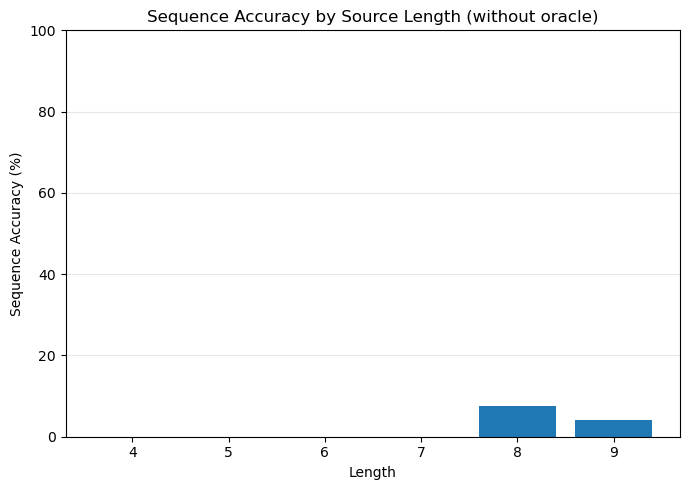

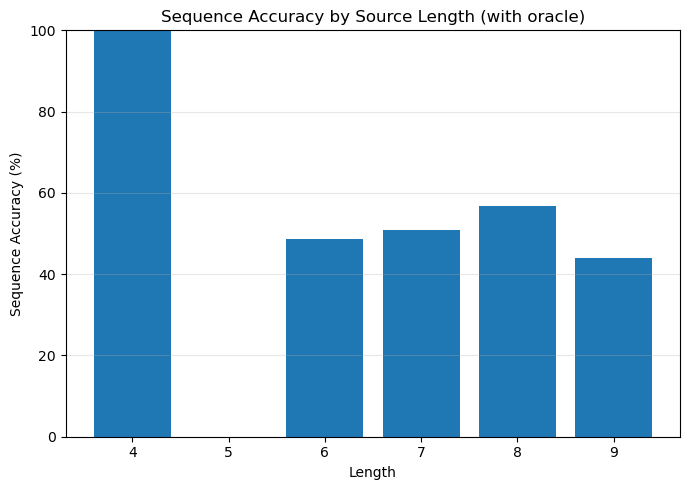

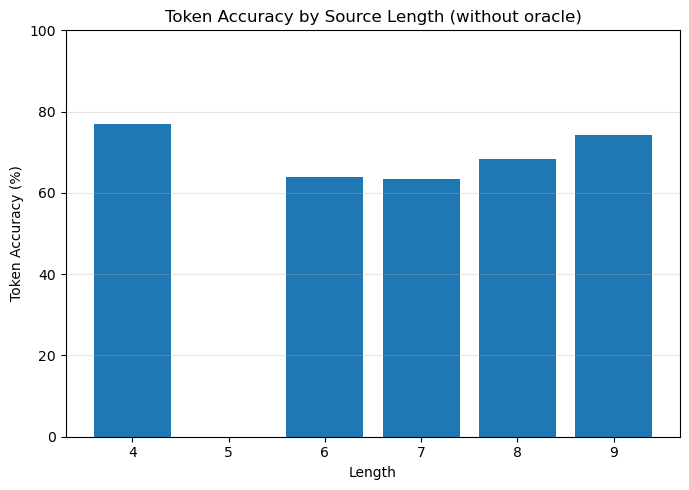

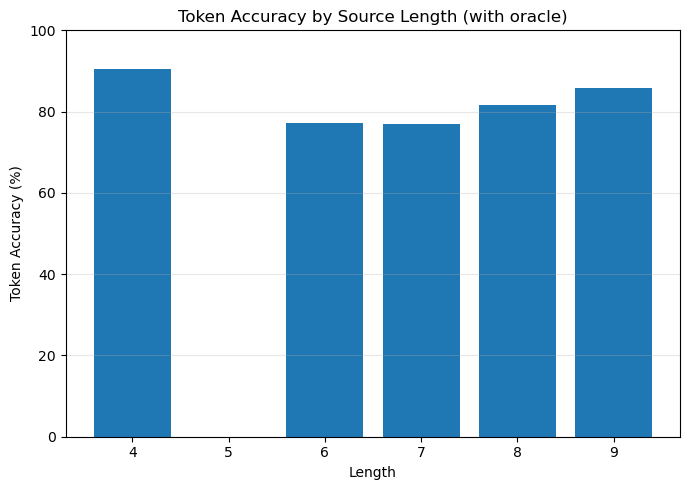

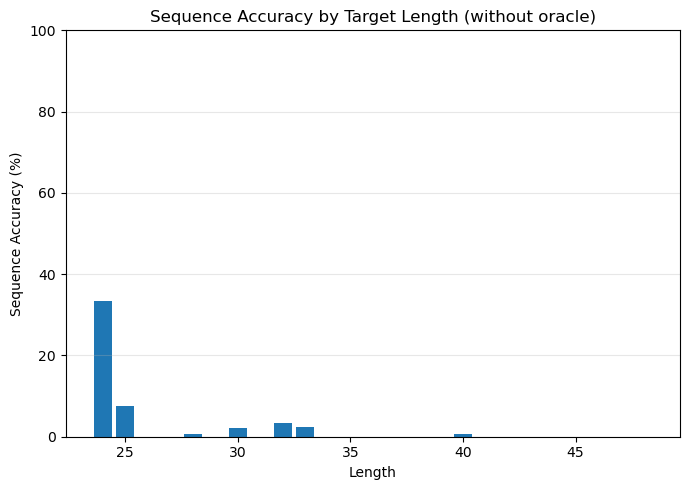

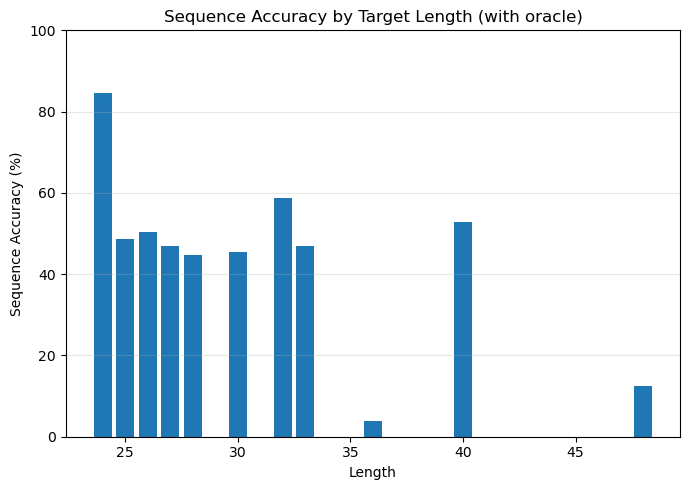

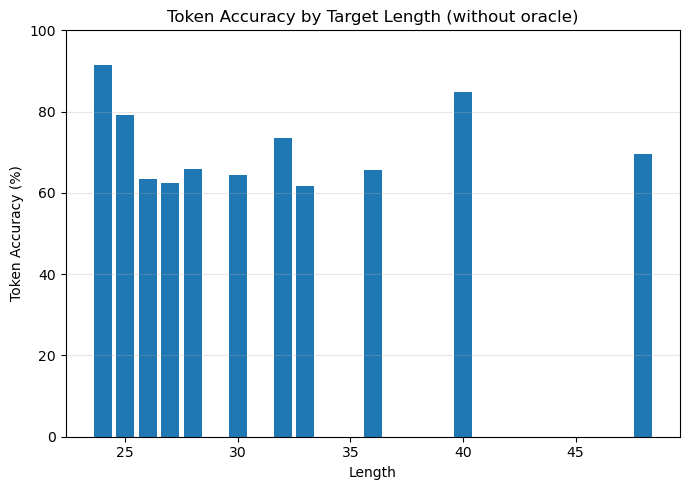

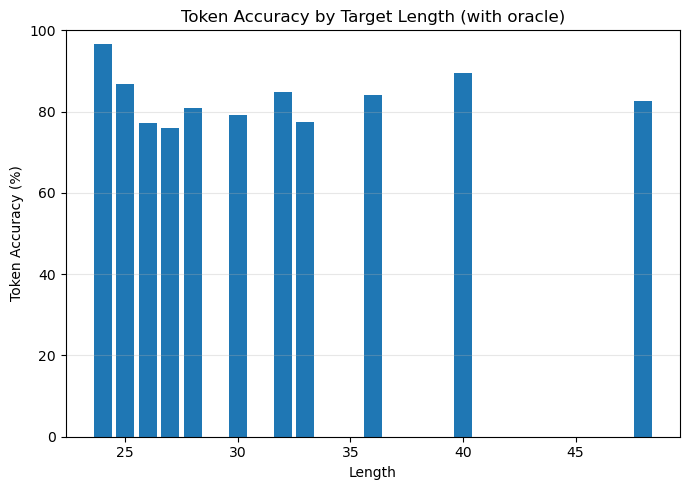

In [14]:
# Source-length plots
exp2_plot_sequence_accuracy(final_results, "source_length", oracle=False)
exp2_plot_sequence_accuracy(final_results, "source_length", oracle=True)

exp2_plot_token_accuracy(final_results, "source_length", oracle=False)
exp2_plot_token_accuracy(final_results, "source_length", oracle=True)

# Target-length plots
exp2_plot_sequence_accuracy(final_results, "target_length", oracle=False)
exp2_plot_sequence_accuracy(final_results, "target_length", oracle=True)

exp2_plot_token_accuracy(final_results, "target_length", oracle=False)
exp2_plot_token_accuracy(final_results, "target_length", oracle=True)


In [15]:
# results = evaluate(all_test_loaders, model, criterion, device)


In [16]:
# # save results as a json file
# import json
# import os

# # create results directory if it doesn't exist
# os.makedirs("results", exist_ok=True)

# with open("results/experiment_2_length_split_results_3.json", "w") as f:
#     json.dump({str(k): v for k, v in results.items()}, f, indent=4)


In [17]:
# # print final results
# """print("\nFinal Results:")
# for experiment, res in results.items():
#     print(f"\nExperiment: {experiment}")
#     for (length_type, length), (seq_acc, tok_acc) in res.items():
#         print(f"  {length_type} length {length}: Seq Acc: {seq_acc*100:.2f}%, Tok Acc: {tok_acc*100:.2f}%")"""

In [18]:
# import matplotlib.pyplot as plt

# def bar_plot(results):
#     """Plot sequence/token accuracy for source/target lengths with/without oracle."""
#     fig, axs = plt.subplots(4, 2, figsize=(14, 12))  # 4 rows (combos), 2 cols (seq/tok)

#     combos = [
#         ("source_length", "without_oracle", "Source length (no oracle)"),
#         ("source_length", "with_oracle", "Source length (with oracle)"),
#         ("target_length", "without_oracle", "Target length (no oracle)"),
#         ("target_length", "with_oracle", "Target length (with oracle)"),
#     ]

#     for row_idx, (len_type, oracle_flag, title) in enumerate(combos):
#         lengths, seq_accs, tok_accs = [], [], []
#         for (k, length, flag), (seq_acc, tok_acc) in results.items():
#             if k == len_type and flag == oracle_flag:
#                 lengths.append(int(length))
#                 seq_accs.append(seq_acc * 100)
#                 tok_accs.append(tok_acc * 100)

#         if not lengths:
#             axs[row_idx, 0].set_visible(False)
#             axs[row_idx, 1].set_visible(False)
#             continue

#         # Sort by length for tidy plotting
#         lengths, seq_accs, tok_accs = zip(*sorted(zip(lengths, seq_accs, tok_accs)))

#         avg_seq_acc = sum(seq_accs) / len(seq_accs)
#         avg_tok_acc = sum(tok_accs) / len(tok_accs)

#         axs[row_idx, 0].bar(lengths, seq_accs, color="b", alpha=0.7)
#         axs[row_idx, 0].set_title(f"{title} - Sequence Accuracy - Avg: {avg_seq_acc:.2f}%")
#         axs[row_idx, 0].set_xlabel("Length")
#         axs[row_idx, 0].set_ylabel("Sequence Accuracy (%)")
#         axs[row_idx, 0].set_ylim(0, 100)

#         axs[row_idx, 1].bar(lengths, tok_accs, color="g", alpha=0.7)
#         axs[row_idx, 1].set_title(f"{title} - Token Accuracy - Avg: {avg_tok_acc:.2f}%")
#         axs[row_idx, 1].set_xlabel("Length")
#         axs[row_idx, 1].set_ylabel("Token Accuracy (%)")
#         axs[row_idx, 1].set_ylim(0, 100)

#     plt.tight_layout()
#     plt.show()

# # Example usage after evaluation:
# # results = evaluate(all_test_loaders, model, criterion, device)
# bar_plot(results)


In [19]:
import importlib
import evaluation_experiment2.scan_evaluation as scan_eval
importlib.reload(scan_eval)

test_eval = scan_eval.evaluate_token_level(model, all_test_loaders["source_length"]["4"], criterion, device, use_oracle=True)
#results = evaluate(all_test_loaders, model, criterion, device)